## Running PC algorithm on generated data

Imporitng required packages

In [208]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from dowhy import CausalModel
import utils_causal
from castle.algorithms import PC
from castle.common import GraphDAG

Loading final dataset in

In [209]:
df_data=pd.read_csv("generated_data_final.csv")
df_data=df_data.drop("Stroke team", axis=1)

In [210]:
df_data

,Onset_during_sleep,Precise_onset_known,AF_patients,AF_patients_on_anticoagulants,Patient age,Disabilities (0-5),Arrival to scan time,Stroke severity,thrombolysis,discharge_disability
0,0,0,0,1,52.5,0,56,5.0,1,1
1,0,1,0,1,77.5,1,35,25.0,1,1
2,0,1,0,1,62.5,0,22,13.0,1,1
3,0,1,0,0,72.5,0,129,9.0,1,1
4,0,1,0,1,62.5,0,579,3.0,1,1
...,...,...,...,...,...,...,...,...,...,...
995,0,1,0,0,72.5,0,3,2.0,1,1
996,0,1,0,1,57.5,0,5,23.0,1,1
997,0,1,0,1,77.5,3,156,3.0,1,1
998,0,0,0,1,37.5,0,35,25.0,1,1


0-0.5 in intervals of 0.1

In [211]:
pc = PC(alpha=0.02)

pc.learn(df_data)

c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


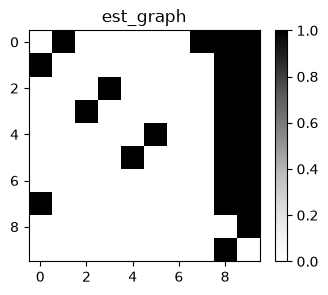

In [212]:
GraphDAG(est_dag=pc.causal_matrix)

In [213]:
import utils_causal

nodes = ['Onset during Sleep', 'Precise onset known', 'AF patient', 'On Anticoagulation', 'Age', 'Prior disability', 'Arrival to scan time','Stroke Severity','Treatment','Outcome']
labels = nodes

nodes_labels = [(n, n) for n in nodes]

edges = []
for i, start_node in enumerate(nodes):
    for j, end_node in enumerate(nodes):
        if pc.causal_matrix[i, j] == 1:
            edges.append((start_node, end_node))

2026-08-03 10:26:07,180 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-08-03 10:26:07,184 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


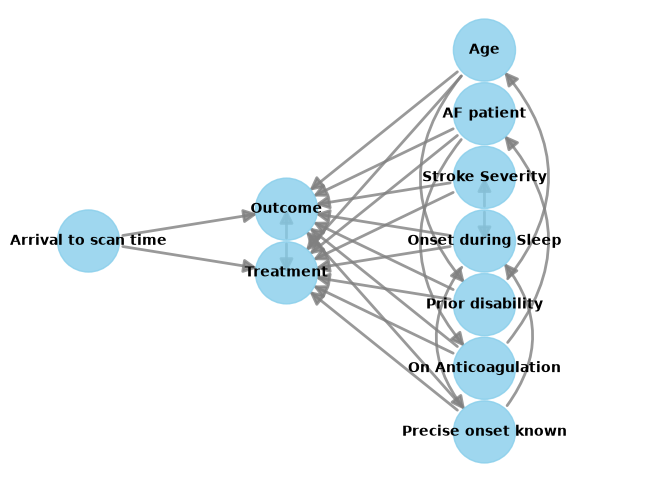

In [227]:
model_test = utils_causal.make_causalmodel_object(nodes_labels, edges)
model_test.view_model()

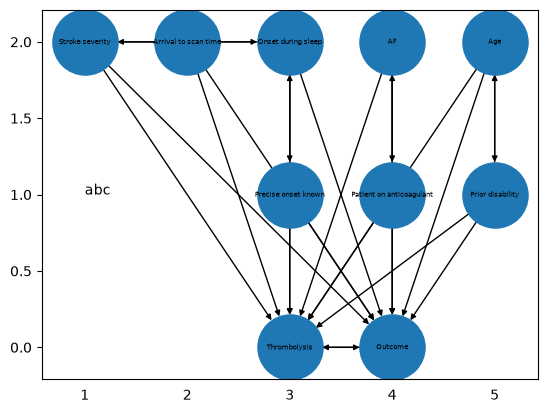

In [226]:
adj_matrix= np.array([
    [0, 1, 0, 0, 0, 0, 0, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 1],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
])

node_names=["Onset during sleep","Precise onset known","AF","Patient on anticoagulant","Age","Prior disability","Arrival to scan time","Stroke severity","Thrombolysis","Outcome"]

G=nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

mapping={i:node_names[i] for i in range(len(node_names))}
G=nx.relabel_nodes(G, mapping)

pos={
    "Onset during sleep":(3,2),
    "Precise onset known":(3,1),
    "AF":(4,2),
    "Patient on anticoagulant":(4,1),
    "Age":(5,2),
    "Prior disability":(5,1),
    "Arrival to scan time":(2,2),
    "Stroke severity":(1,2),
    "Thrombolysis":(3,0),
    "Outcome":(4,0)
}

fig,ax=plt.subplots()

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    arrows=True,
    node_size=2200,
    font_size=5,
    arrowsize=8,
    ax=ax
)
ax.annotate("abc",xy=(1,1))
#ax.set_xticks(ax.get_xticks(),visible=True)
ax.tick_params(left=True,labelleft=True,labelbottom=True)

![Real DAG](real_causal.png)